# Phase 5: Graph Analysis — Topological Intelligence
## AI Quant Research System

Construction is complete; now we analyze. In this notebook, we treat the market as a physical network. We identify which assets are the "hubs" of the system and which act as "bridges" between sectors.

**Topological Alpha:**
*   **Centrality:** Hub stocks often lead the market or transmit volatility.
*   **Community Detection:** If a stock "leaves" its sector community and joins another, it's a signal of a fundamental regime shift.
*   **Systemic Risk:** Assets with high betweenness are the "choke points" of the market; their failure (crash) is more likely to cause a systemic contagion.


---
## Cell 2 — Imports & Load Topology


In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings('ignore')

# Global Viz
plt.rcParams.update({"figure.facecolor": "#0d0d0d", "axes.facecolor": "#111111", "text.color": "white"})
COLORS = ["#00D4FF","#FF6B6B","#51CF66","#FFD43B","#CC5DE8","#FF922B","#74C0FC","#F783AC"]

# Paths
PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR = Path('../data/outputs')
RAW_DIR = Path('../data/raw')

# Load MST
mst_edges = pd.read_csv(PROCESSED_DIR / 'mst_edges.csv')
MST = nx.from_pandas_edgelist(mst_edges, source='source', target='target', edge_attr='weight')
with open(RAW_DIR / 'sector_map.json', 'r') as f:
    sector_map = json.load(f)

print(f"Graph loaded with {len(MST.nodes)} nodes.")


Graph loaded with 30 nodes.


---
## Cell 3 — Centrality Analysis: Identifying the Market Hubs


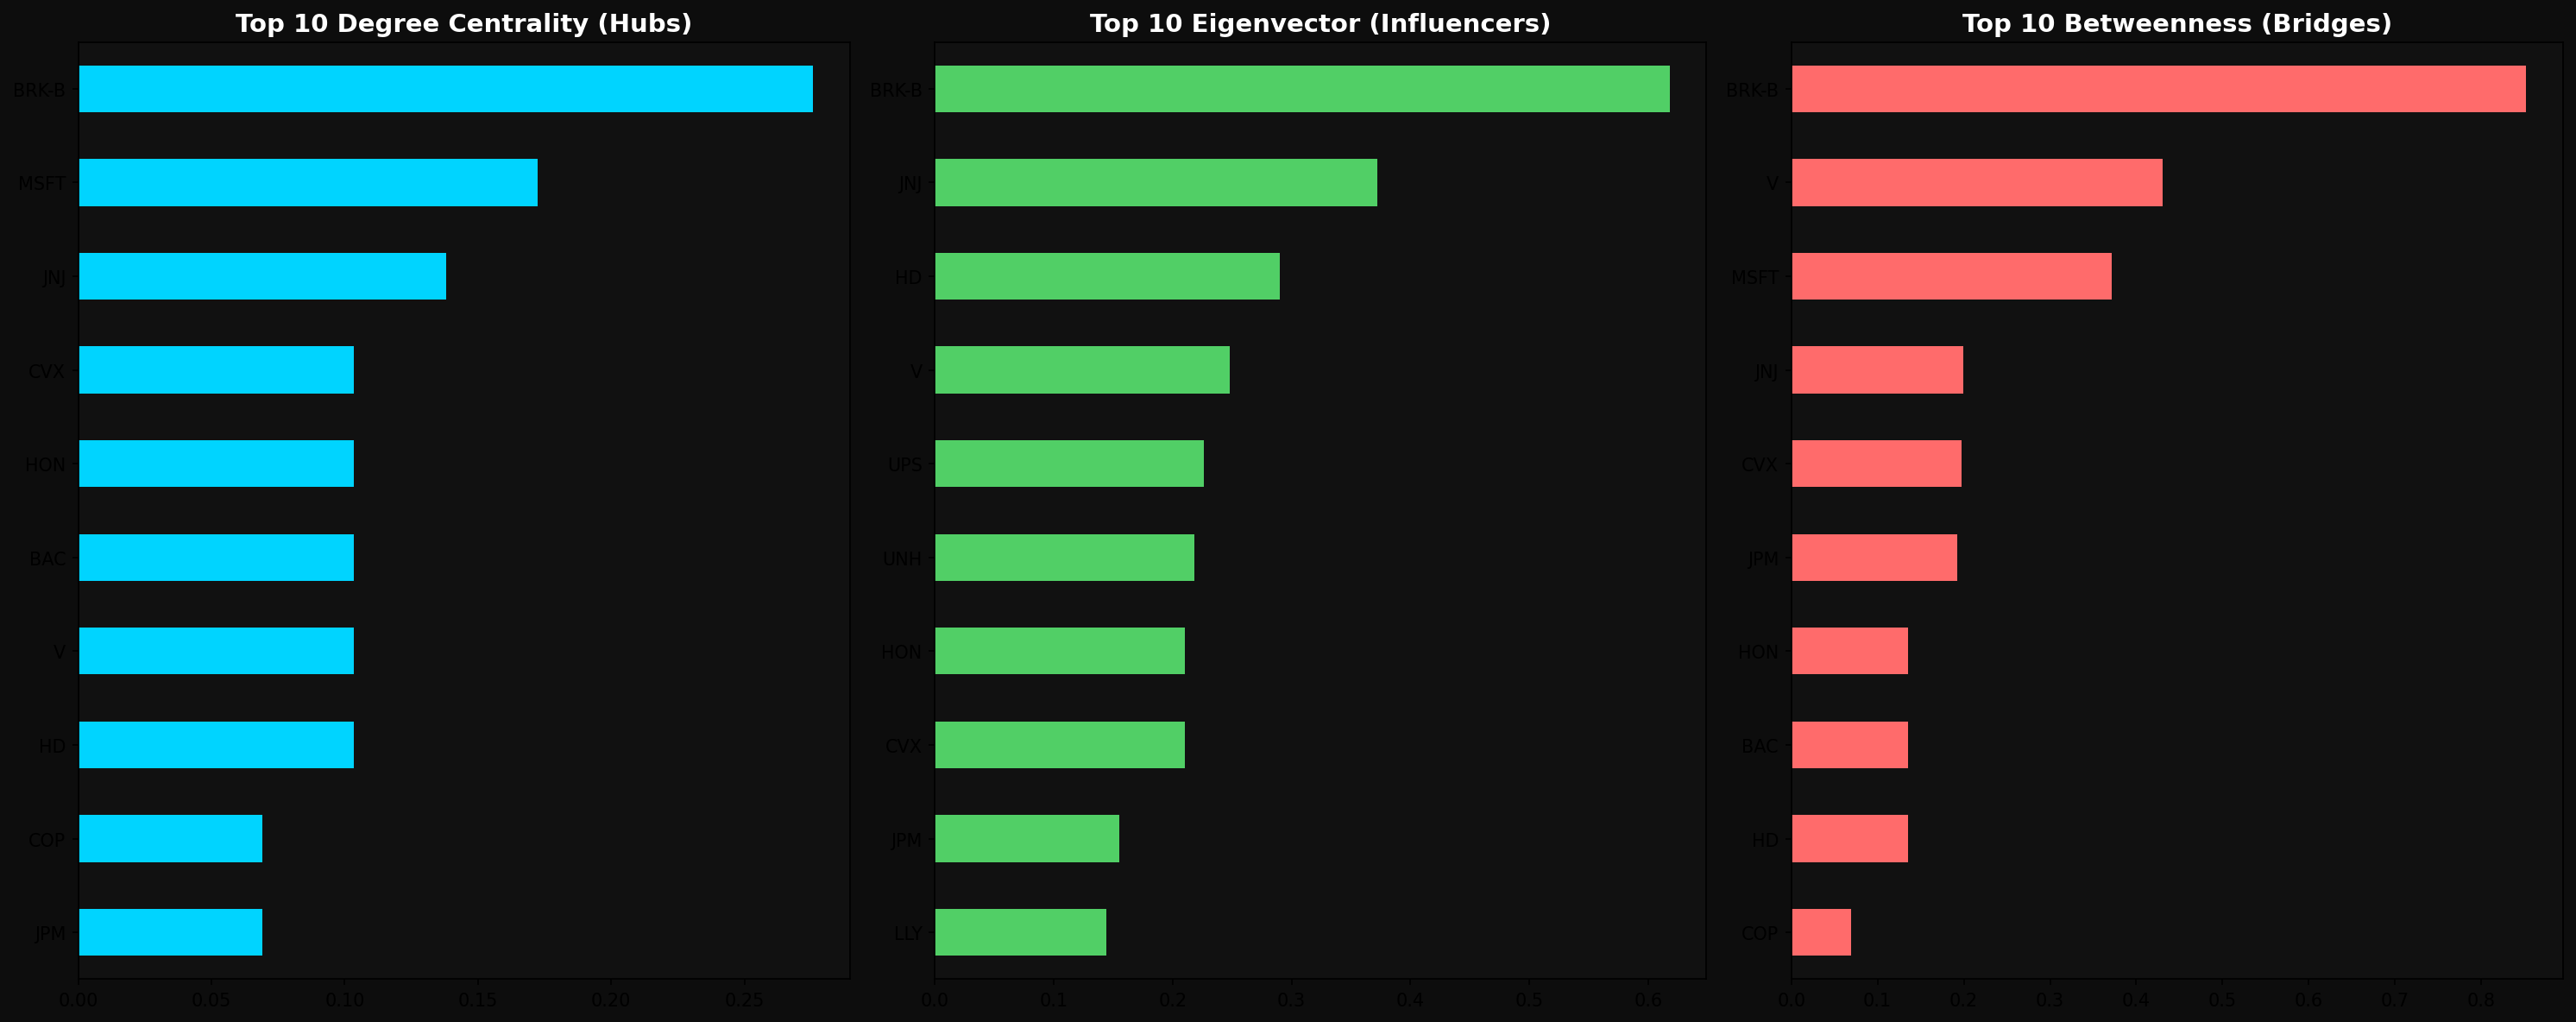

In [3]:
# 1. Degree Centrality (Most connected)
degree = nx.degree_centrality(MST)

# 2. Eigenvector Centrality (Most connected to other important nodes)
eigen = nx.eigenvector_centrality(MST, weight='weight')

# 3. Betweenness Centrality (Bridges between clusters)
between = nx.betweenness_centrality(MST)

topo_df = pd.DataFrame({
    'degree': degree,
    'eigenvector': eigen,
    'betweenness': between
})
topo_df['sector'] = topo_df.index.map(sector_map)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 8), dpi=150)

topo_df['degree'].sort_values().tail(10).plot(kind='barh', ax=axes[0], color=COLORS[0])
axes[0].set_title('Top 10 Degree Centrality (Hubs)', fontsize=14, fontweight='bold')

topo_df['eigenvector'].sort_values().tail(10).plot(kind='barh', ax=axes[1], color=COLORS[2])
axes[1].set_title('Top 10 Eigenvector (Influencers)', fontsize=14, fontweight='bold')

topo_df['betweenness'].sort_values().tail(10).plot(kind='barh', ax=axes[2], color=COLORS[1])
axes[2].set_title('Top 10 Betweenness (Bridges)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig_centrality_metrics.png')
plt.show()


---
## Cell 4 — Community Detection (Louvain)
We use the Louvain method to detect clusters. We then compare these "unsupervised" clusters with our "supervised" sectors.


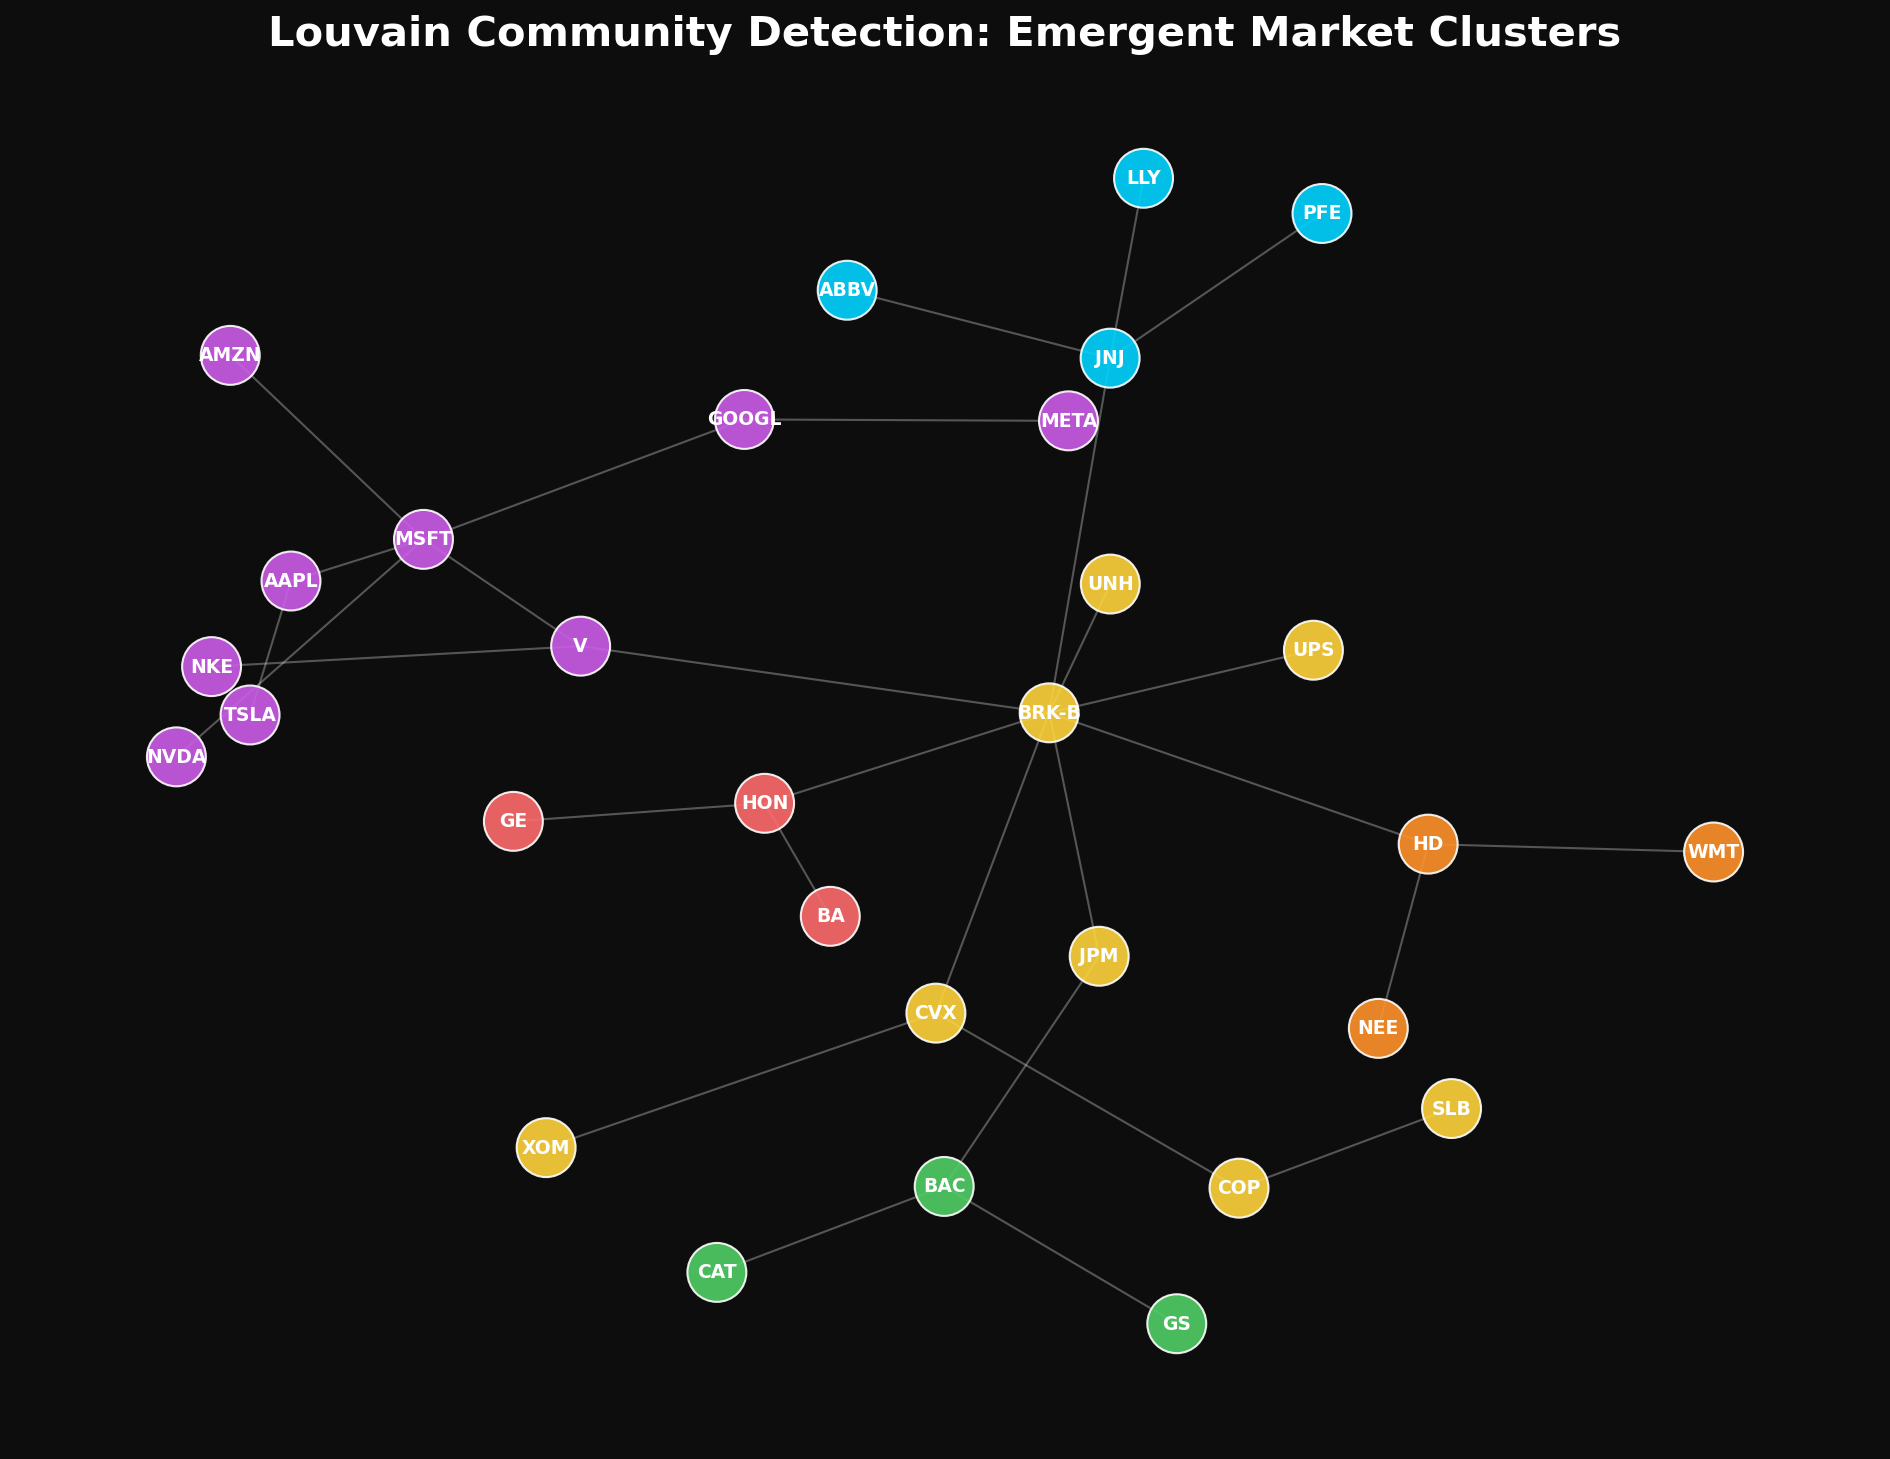

In [4]:
from networkx.algorithms import community

# Detect communities
communities = community.louvain_communities(MST, seed=42)
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

topo_df['community'] = topo_df.index.map(community_map)

# Visualization
plt.figure(figsize=(16, 12), dpi=150)
pos = nx.spring_layout(MST, k=0.5, seed=42)
node_colors = [COLORS[community_map[n] % len(COLORS)] for n in MST.nodes()]

nx.draw_networkx_nodes(MST, pos, node_size=800, node_color=node_colors, alpha=0.9, edgecolors='white')
nx.draw_networkx_edges(MST, pos, alpha=0.3, edge_color='white')
nx.draw_networkx_labels(MST, pos, font_size=9, font_color='white', font_weight='bold')

plt.title('Louvain Community Detection: Emergent Market Clusters', fontsize=20, fontweight='bold')
plt.axis('off')
plt.savefig(OUTPUTS_DIR / 'fig_market_communities.png')
plt.show()


---
## Cell 5 — Topo-Feature Export
We merge these topological metrics into our master feature set for the ML phase.


In [5]:
# Merge with risk metrics
risk_metrics = pd.read_csv(PROCESSED_DIR / 'risk_metrics.csv', index_col=0)
final_topo_features = risk_metrics.join(topo_df.drop(columns='sector'))

final_topo_features.to_csv(PROCESSED_DIR / 'graph_intelligence.csv')
print("Topological features exported to data/processed/graph_intelligence.csv")
display(final_topo_features.head())


Topological features exported to data/processed/graph_intelligence.csv


,ann_ret,ann_vol,VaR_99,CVaR_99,max_drawdown,sharpe,sortino,calmar,sector,degree,eigenvector,betweenness,community
AAPL,0.317563,0.308504,-0.053032,-0.073110,-0.351789,1.029361,1.379027,0.902708,Technology,0.068966,0.034819,0.068966,4
ABBV,0.158725,0.255034,-0.044178,-0.077613,-0.357496,0.622370,0.702386,0.443992,Healthcare,0.034483,0.141331,0.000000,0
AMZN,0.176513,0.341341,-0.056688,-0.077527,-0.618939,0.517117,0.722139,0.285187,Consumer,0.034483,0.032953,0.000000,4
BA,-0.096562,0.482548,-0.078520,-0.133751,-0.845069,-0.200109,-0.253593,-0.114266,Industrials,0.034483,0.068435,0.000000,1
BAC,0.118932,0.338862,-0.054587,-0.081963,-0.525541,0.350975,0.479317,0.226304,Financials,0.103448,0.030225,0.135468,2
